# Notebook 04: Model Evaluation

## Objective

This notebook evaluates the trained EfficientNet-B2 model using the independent test dataset.

The following evaluation metrics will be generated:

- Test Loss
- Test Accuracy
- Confusion Matrix
- Classification Report
- Precision
- Recall
- F1-score
- ROC Curve
- AUC Score
- Misclassified Samples

All evaluation figures and reports will be saved in the `results/` directory.

In [11]:
# ============================================================
# Import Required Libraries
# ============================================================

from pathlib import Path
import copy

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from torchvision import datasets, transforms
from torchvision.models import (
    efficientnet_b2,
    EfficientNet_B2_Weights
)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize

sns.set_theme(style="whitegrid")

print("=" * 60)
print("✅ Libraries Imported Successfully")
print("=" * 60)

✅ Libraries Imported Successfully


# Project Configuration

Define all project paths, device configuration, and create the required output directories for model evaluation.

In [12]:
# ============================================================
# Project Configuration
# ============================================================

from pathlib import Path

# Project Root
PROJECT_DIR = Path.cwd()

# Dataset
DATASET_DIR = PROJECT_DIR / "dataset" / "processed_dataset"

# Test Dataset
TEST_DIR = DATASET_DIR / "test"

# Saved Model
MODEL_PATH = PROJECT_DIR / "models" / "best_model.pth"

# Results Folder
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("Project Directory :", PROJECT_DIR.resolve())
print("Test Dataset      :", TEST_DIR.resolve())
print("Model             :", MODEL_PATH.resolve())
print("Results Folder    :", RESULTS_DIR.resolve())
print("Device            :", DEVICE)
print("=" * 60)

Project Directory : /mnt/g/Research paper/Research paper/Pneumonia-EfficientNetB0-XAI
Test Dataset      : /mnt/g/Research paper/Research paper/Pneumonia-EfficientNetB0-XAI/dataset/processed_dataset/test
Model             : /mnt/g/Research paper/Research paper/Pneumonia-EfficientNetB0-XAI/models/best_model.pth
Results Folder    : /mnt/g/Research paper/Research paper/Pneumonia-EfficientNetB0-XAI/results
Device            : cuda


# Dataset and Model Configuration

Configure the image preprocessing pipeline, batch size, class names, and model input parameters for evaluation.

In [13]:
# ============================================================
# Dataset and Model Configuration
# ============================================================

# Image Size
IMAGE_SIZE = 260          # EfficientNet-B2 default input size

# Batch Size
BATCH_SIZE = 32

# Number of Workers
NUM_WORKERS = 0

# Number of Classes
NUM_CLASSES = 3

# Class Names
CLASS_NAMES = [
    "BACTERIA",
    "NORMAL",
    "VIRUS"
]

# Test Transform
test_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

])

print("=" * 60)
print("Image Size     :", IMAGE_SIZE)
print("Batch Size     :", BATCH_SIZE)
print("Classes        :", CLASS_NAMES)
print("=" * 60)

Image Size     : 260
Batch Size     : 32
Classes        : ['BACTERIA', 'NORMAL', 'VIRUS']


# Load Test Dataset

Load the test dataset, create the DataLoader, and verify the dataset structure before model evaluation.

In [14]:
# ============================================================
# Load Test Dataset
# ============================================================

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("=" * 60)
print("✅ Test Dataset Loaded Successfully")
print("=" * 60)

print(f"Number of Classes : {len(test_dataset.classes)}")
print(f"Class Names       : {test_dataset.classes}")
print(f"Total Test Images : {len(test_dataset)}")

print("\nClass Mapping")
print("-" * 30)

for idx, class_name in enumerate(test_dataset.classes):
    print(f"{idx} --> {class_name}")

print("=" * 60)

✅ Test Dataset Loaded Successfully
Number of Classes : 3
Class Names       : ['BACTERIA', 'NORMAL', 'VIRUS']
Total Test Images : 879

Class Mapping
------------------------------
0 --> BACTERIA
1 --> NORMAL
2 --> VIRUS


# Load Trained EfficientNet-B2 Model

Load the trained EfficientNet-B2 model with the saved best weights and prepare it for evaluation.

In [20]:
# ============================================================
# Load Trained EfficientNet-B2 Model
# ============================================================

MODEL_PATH = PROJECT_DIR / "models" / "best_model.pth"

print("=" * 60)
print("Loading model...")
print(MODEL_PATH)
print("=" * 60)

# Create Model
weights = EfficientNet_B2_Weights.DEFAULT

model = efficientnet_b2(weights=weights)

# IMPORTANT:
# Must be identical to Notebook 03

in_features = model.classifier[1].in_features

model.classifier[1] = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features, NUM_CLASSES)
)

# Load checkpoint
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)

# Load state dict
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model = model.to(DEVICE)
model.eval()

print("\n" + "=" * 60)
print("✅ Best Model Loaded Successfully")
print("=" * 60)
print(model.classifier)
print("=" * 60)

Loading model...
/mnt/g/Research paper/Research paper/Pneumonia-EfficientNetB0-XAI/models/best_model.pth

✅ Best Model Loaded Successfully
Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Sequential(
    (0): Dropout(p=0.4, inplace=False)
    (1): Linear(in_features=1408, out_features=3, bias=True)
  )
)


# Model Evaluation

Run inference on the test dataset and collect predictions, probabilities, and evaluation metrics.

In [21]:
# ============================================================
# Evaluate Model on Test Dataset
# ============================================================

criterion = nn.CrossEntropyLoss()

model.eval()

all_labels = []
all_predictions = []
all_probabilities = []

test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item()

        probabilities = torch.softmax(outputs, dim=1)

        _, predictions = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

# Convert to NumPy
all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)

test_loss /= len(test_loader)
test_accuracy = correct / total

print("=" * 60)
print("✅ Model Evaluation Completed")
print("=" * 60)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print("=" * 60)

✅ Model Evaluation Completed
Test Loss     : 0.3924
Test Accuracy : 0.8692


# Classification Metrics

Generate the classification report and compute the overall Precision, Recall, and F1-score for the test dataset.

In [22]:
# ============================================================
# Classification Report
# ============================================================

from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

report = classification_report(
    all_labels,
    all_predictions,
    target_names=CLASS_NAMES,
    digits=4
)

precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted"
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted"
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted"
)

print("=" * 60)
print("Classification Report")
print("=" * 60)
print(report)

print("=" * 60)
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("=" * 60)

Classification Report
              precision    recall  f1-score   support

    BACTERIA     0.8759    0.8801    0.8780       417
      NORMAL     0.9216    0.9874    0.9533       238
       VIRUS     0.7902    0.7232    0.7552       224

    accuracy                         0.8692       879
   macro avg     0.8626    0.8636    0.8622       879
weighted avg     0.8664    0.8692    0.8671       879

Precision : 0.8664
Recall    : 0.8692
F1-Score  : 0.8671


# Confusion Matrix

Generate and visualize the confusion matrix to analyze the prediction performance of the model for each class.

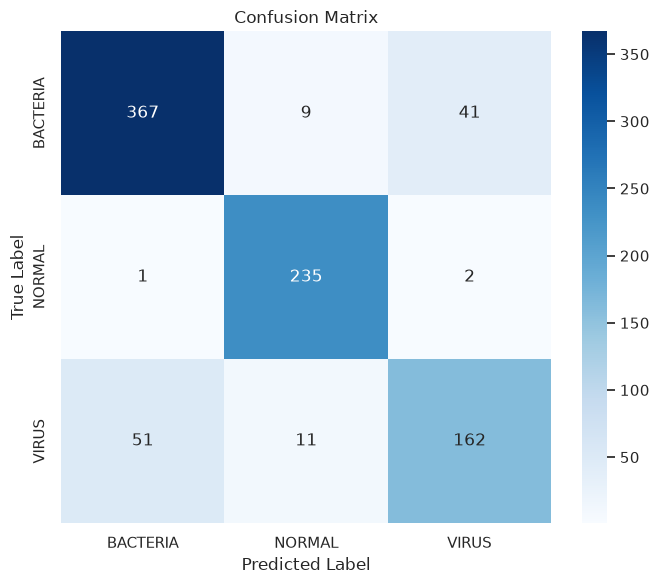

✅ Confusion Matrix saved successfully.


In [23]:
# ============================================================
# Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Confusion Matrix saved successfully.")